In [1]:
# =============================================================================
# 13 — Per structure visual and quantitative analysis
#
# GEOMETRY must match 12a, 12b, 12c.
#
# Supervisor requests addressed here
#   6  union overlap first, then per label, then stratified
#   7  per label table with n, Dice, GradCAM versus FinerCAM
#   5  normalise for structure size
#   4  threshold fixed in advance, sweep reported as robustness only
#
# THRESHOLD PROVENANCE
#   The top 10 percent cut was fixed before any of this analysis, inherited
#   from the 08b clinician review pipeline. The sweep in Cell 6 is a reported
#   robustness check. It is not used to select the threshold.
#
# Writes to results/structure/<pool>/<geometry>/
# =============================================================================
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import cv2
from PIL import Image
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


def find_repo_root() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "scripts" / "generate_finer_cam_panderm.py").exists():
            return p.resolve()
    raise FileNotFoundError


REPO = find_repo_root()
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

from src.eval.cam_eval_utils import (
    transform_mask, mask_to_cam_grid_geom, transform_rgb, cam_to_grid,
    norm01, CAM_GRID, CROP_SIZE, patch_footprint)

# ---- switches, must match 12a, 12b, 12c -----------------------------------
GEOMETRY = "squash224"
POOLING  = "mean"
POOL_TAG = "gap" if POOLING == "mean" else "cls"
CKPT     = "ha5"
GAMMA    = "0p6"

HAM_ROOT  = REPO / "data" / "HAM10000"
EVAL_ROOT = REPO / "outputs" / "mel_nv" / "eval_cams" / POOL_TAG / GEOMETRY
OVERLAP   = REPO / "results" / "overlap" / POOL_TAG / GEOMETRY
QC_CSV    = REPO / "results" / "annotation_qc" / GEOMETRY / "annotation_qc_manifest.csv"
OUT       = REPO / "results" / "structure" / POOL_TAG / GEOMETRY
PER_IMG   = OUT / "per_image"
PER_IMG.mkdir(parents=True, exist_ok=True)

MAIN_PCT   = 10
SWEEP_PCTS = [5, 10, 15, 20, 30]
MIN_N      = 4

for p in [EVAL_ROOT, QC_CSV, OVERLAP / "overlap_metrics_long.csv"]:
    if not p.exists():
        raise FileNotFoundError(f"missing {p}. Run 12a/12b/12c with "
                                f"GEOMETRY={GEOMETRY} first.")

qc      = pd.read_csv(QC_CSV).query("qc_pass")
pred    = pd.read_csv(EVAL_ROOT / "predictions.csv")
eval_df = pd.read_csv(EVAL_ROOT / "eval_images.csv")
long_df = pd.read_csv(OVERLAP / "overlap_metrics_long.csv")

labels_all = sorted(qc.label.unique())
_pal = plt.cm.tab20(np.linspace(0, 1, 20))
LABEL_COLOR = {l: _pal[i] for i, l in enumerate(labels_all)}

CAM_COLS = [
    ("gradcam_a", "GradCAM target"),
    ("gradcam_b", "GradCAM reference"),
    ("map_diff",  "Diff"),
    ("finercam",  "Finer-CAM"),
]

mpl.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 220, "savefig.bbox": "tight",
    "font.size": 8, "axes.spines.top": False, "axes.spines.right": False,
})

fy, fx = patch_footprint(GEOMETRY)
print(f"geometry {GEOMETRY}   pooling {POOL_TAG}   checkpoint {CKPT}   gamma {GAMMA}")
print(f"labels {len(labels_all)}   annotations {len(qc)}   "
      f"images {qc.Image_ID.nunique()}")
print(f"one patch covers {fy:.1f} x {fx:.1f} original px")
print(f"threshold {MAIN_PCT}% fixed in advance. sweep {SWEEP_PCTS} is "
      f"robustness only.")

geometry squash224   pooling gap   checkpoint ha5   gamma 0p6
labels 15   annotations 100   images 34
one patch covers 32.1 x 42.9 original px
threshold 10% fixed in advance. sweep [5, 10, 15, 20, 30] is robustness only.


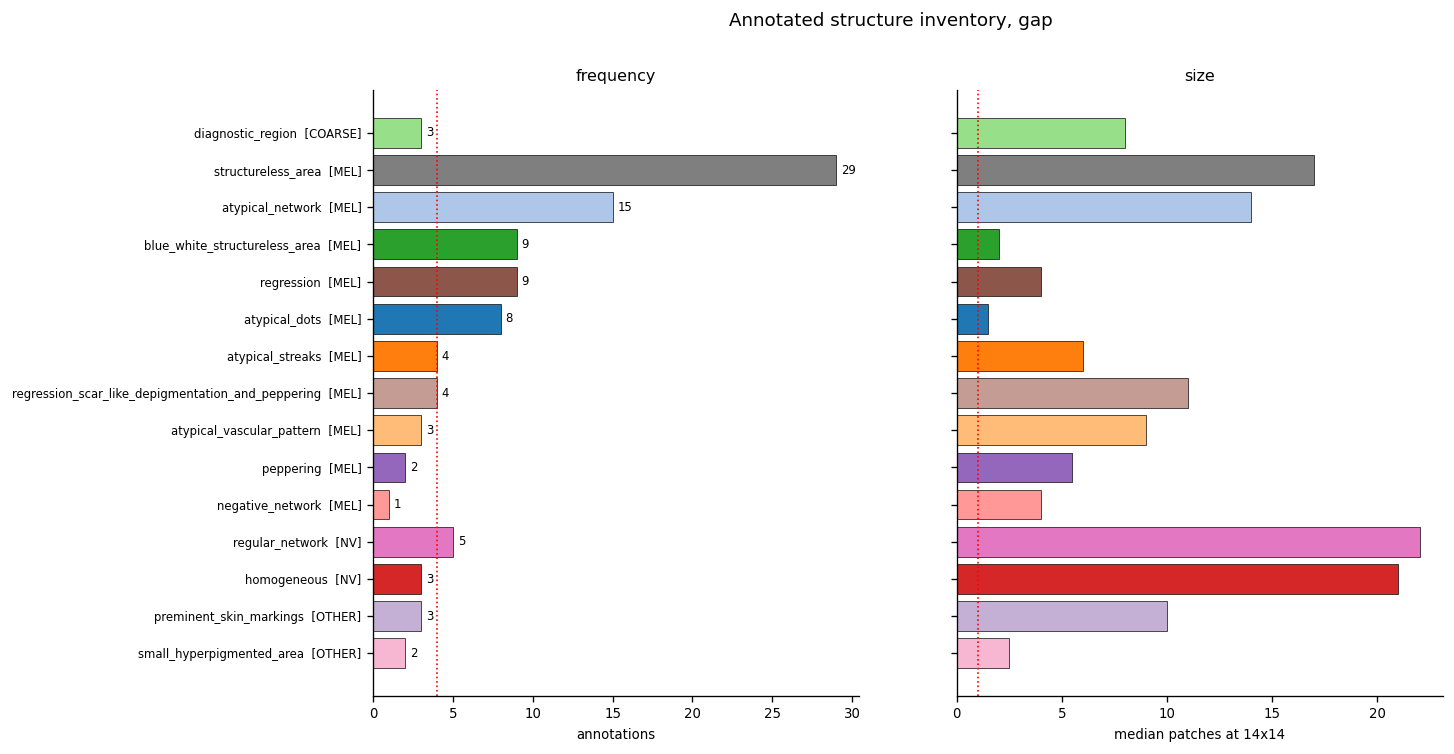

label_group                                             label  n  images  med_patches  med_area  med_inside
     COARSE                                 diagnostic_region  3       3          8.0     0.041       1.000
        MEL                                structureless_area 29      29         17.0     0.087       1.000
        MEL                                  atypical_network 15      15         14.0     0.071       0.999
        MEL                     blue_white_structureless_area  9       9          2.0     0.010       1.000
        MEL                                        regression  9       9          4.0     0.020       1.000
        MEL                                     atypical_dots  8       8          1.5     0.008       1.000
        MEL                                  atypical_streaks  4       4          6.0     0.031       0.980
        MEL regression_scar_like_depigmentation_and_peppering  4       4         11.0     0.056       1.000
        MEL                 

In [2]:
# =============================================================================
# FIGURE 13.1  What was annotated, how often, how large.
#
# EXPECT structureless_area dominant at 29. focal labels rare and small.
# READ   any label below n=4 cannot support a claim.
#        the red line at 1 patch is the resolution floor. anything near it
#        cannot be localised at 14x14 regardless of model quality.
# =============================================================================
inv = (qc.groupby(["label_group", "label"])
         .agg(n=("label", "size"),
              images=("Image_ID", "nunique"),
              med_patches=("n_patch_50", "median"),
              med_area=("grid_area_frac", "median"),
              med_inside=("frac_inside_lesion", "median"))
         .reset_index()
         .sort_values(["label_group", "n"], ascending=[True, False]))

fig, ax = plt.subplots(1, 2, figsize=(11.5, 0.33 * len(inv) + 1.6))
y = np.arange(len(inv))
cols = [LABEL_COLOR[l] for l in inv.label]

ax[0].barh(y, inv.n, color=cols, edgecolor="black", linewidth=0.4)
ax[0].axvline(MIN_N, color="red", ls=":", lw=1)
ax[0].set_yticks(y)
ax[0].set_yticklabels([f"{r.label}  [{r.label_group}]"
                       for _, r in inv.iterrows()], fontsize=7)
ax[0].invert_yaxis()
ax[0].set_xlabel("annotations")
ax[0].set_title("frequency")
for i, v in enumerate(inv.n):
    ax[0].text(v + 0.3, i, str(v), va="center", fontsize=7)

ax[1].barh(y, inv.med_patches, color=cols, edgecolor="black", linewidth=0.4)
ax[1].axvline(1, color="red", ls=":", lw=1)
ax[1].set_yticks(y)
ax[1].set_yticklabels([])
ax[1].invert_yaxis()
ax[1].set_xlabel(f"median patches at {CAM_GRID}x{CAM_GRID}")
ax[1].set_title("size")

fig.suptitle(f"Annotated structure inventory, {POOL_TAG}", fontsize=11)
fig.savefig(OUT / "label_distribution.png")
plt.show()

print(inv.round(3).to_string(index=False))
print(f"\nusable at n >= {MIN_N}: "
      f"{int((inv.n >= MIN_N).sum())} of {len(inv)} labels")

In [3]:
def cropped_rgb(image_id):
    """Display view. Named cropped_rgb for backwards compatibility,
    actually applies GEOMETRY, which may squash rather than crop."""
    rel = eval_df.set_index("image_id").loc[image_id, "image_rel_path"]
    img = np.array(Image.open((HAM_ROOT / str(rel)).resolve()).convert("RGB"))
    return transform_rgb(img, GEOMETRY)


def label_masks(image_id):
    """{label: (mask_224 bool, grid_14 bool)}, both under GEOMETRY."""
    out = {}
    for _, r in qc[qc.Image_ID == image_id].iterrows():
        m = np.array(Image.open(r.mask_path).convert("L")) > 127
        crop, _ = transform_mask(m, GEOMETRY)
        grid = mask_to_cam_grid_geom(m, GEOMETRY) >= 0.5
        out[r.label] = (crop, grid)
    return out


def load_cam(image_id, cam_type):
    sub = f"act__{CKPT}__g{GAMMA}" if cam_type == "finercam" else f"act__{CKPT}__g0p6"
    f = EVAL_ROOT / sub / "raw_cams" / f"{image_id}_{cam_type}.npy"
    return cam_to_grid(np.load(f)) if f.exists() else None


def topk_mask(cam_grid, pct):
    k = max(1, int(round(pct / 100 * cam_grid.size)))
    flat = norm01(cam_grid).ravel()
    out = np.zeros(flat.size, bool)
    out[np.argpartition(-flat, k - 1)[:k]] = True
    return out.reshape(cam_grid.shape)


def structure_metrics(cam_grid, struct_grid, pct):
    """
    Overlap between a top-k CAM selection and one annotated structure.

    RAW
      struct_covered  fraction of the STRUCTURE reached by the top heat.
                      answers: did the model see it.
      heat_on_struct  fraction of the HEAT landing on this structure.
                      answers: was the model looking at this.
      dice            symmetric overlap. penalises misses and spill.
      iou             same information as dice, monotonically related.
      lift            struct_covered divided by chance. 1.0 is chance.

    NORMALISED  both raw coverage and Dice are bounded by the ratio of
    selection size to structure size at a fixed top-k. A structure larger
    than k can never be fully covered and a structure much smaller than k
    can never reach Dice 1.0. Ranking on raw values ranks by structure
    size. These two columns remove that.

      cov_norm    (coverage - chance) / (ceiling - chance). 1.0 means the
                  model did as well as the top-k budget allows.
      dice_norm   dice divided by its achievable ceiling.
    """
    n_tgt = int(struct_grid.sum())
    keys = ["struct_covered", "heat_on_struct", "dice", "iou", "lift",
            "cov_ceiling", "cov_norm", "dice_max", "dice_norm"]
    if n_tgt == 0:
        return {k: np.nan for k in keys}

    sel = topk_mask(cam_grid, pct)
    n_sel = int(sel.sum())
    n_all = int(struct_grid.size)
    inter = int((sel & struct_grid).sum())

    sc = inter / n_tgt
    chance_cov = n_sel / n_all
    ceil_cov = min(1.0, n_sel / n_tgt)

    dice = 2 * inter / (n_sel + n_tgt + 1e-8)
    dice_max = 2 * min(n_sel, n_tgt) / (n_sel + n_tgt + 1e-8)

    # a structure covering the whole grid cannot be discriminated
    denom = ceil_cov - chance_cov
    cov_norm = (sc - chance_cov) / denom if denom > 1e-6 else np.nan

    return {
        "struct_covered": float(sc),
        "heat_on_struct": float(inter / n_sel),
        "dice":           float(dice),
        "iou":            float(inter / ((sel | struct_grid).sum() + 1e-8)),
        "lift":           float(sc / chance_cov),
        "cov_ceiling":    float(ceil_cov),
        "cov_norm":       float(cov_norm) if not np.isnan(cov_norm) else np.nan,
        "dice_max":       float(dice_max),
        "dice_norm":      float(dice / (dice_max + 1e-8)),
    }

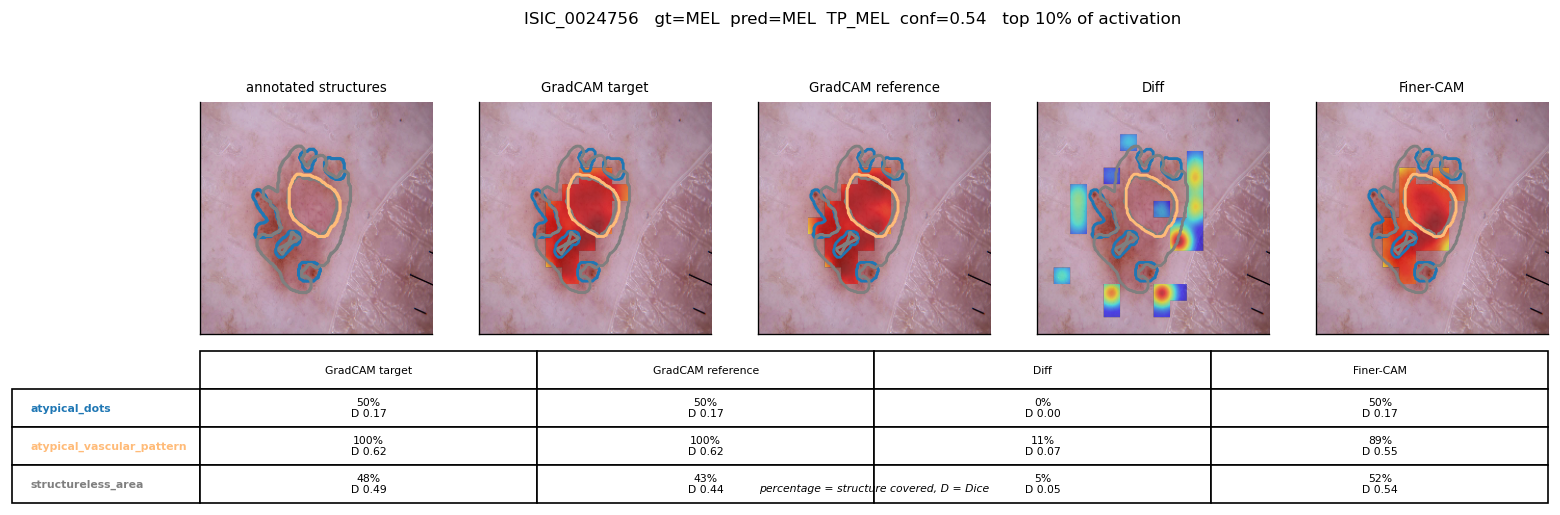

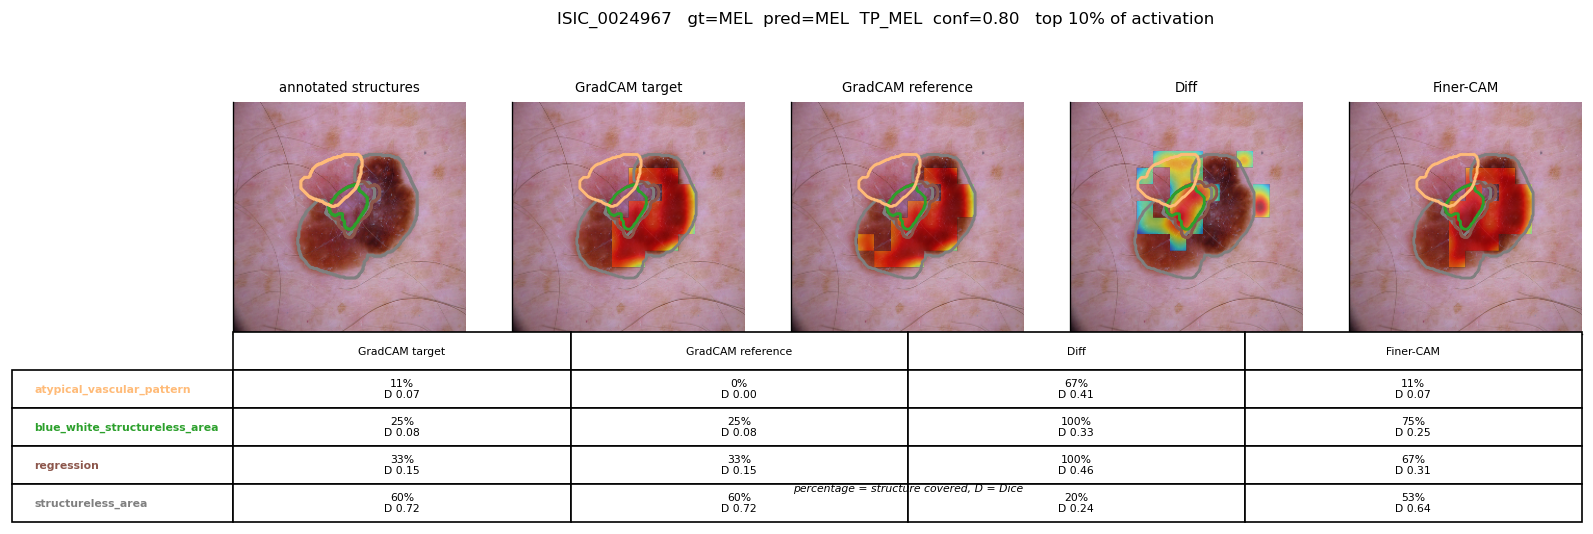

In [4]:
# =============================================================================
# FIGURE 13.2  One per image.
#
# Columns  annotated structures, then the four CAM types with top 10% heat.
# Outlines are the clinician structures, fixed colour per label.
# Table underneath gives structure coverage and Dice per CAM.
#
# EXPECT at alpha=5 all four CAMs look near identical. That is the E4 finding
#        made visible at the level of individual structures.
# WATCH  which structures the heat reaches and which it never touches.
# =============================================================================
def structure_figure(image_id, pct=MAIN_PCT, save=True, show=True):
    rgb = cropped_rgb(image_id)
    masks = label_masks(image_id)
    if not masks:
        return None
    p = pred[pred.image_id == image_id].iloc[0]

    ncol = 1 + len(CAM_COLS)
    fig = plt.figure(figsize=(2.9 * ncol, 4.4))
    gs = fig.add_gridspec(2, ncol, height_ratios=[3.0, 1.3], hspace=0.06)

    ax0 = fig.add_subplot(gs[0, 0])
    ax0.imshow(rgb)
    for lab, (m224, _) in masks.items():
        ax0.contour(m224.astype(float), [0.5],
                    colors=[LABEL_COLOR[lab]], linewidths=1.9)
    ax0.set_title("annotated structures", fontsize=8)
    ax0.set_xticks([]); ax0.set_yticks([])

    rows = []
    for j, (ct, name) in enumerate(CAM_COLS, start=1):
        cam = load_cam(image_id, ct)
        a = fig.add_subplot(gs[0, j])
        a.imshow(rgb)
        if cam is not None:
            sel = topk_mask(cam, pct)
            up = cv2.resize(sel.astype(np.float32), (CROP_SIZE, CROP_SIZE),
                            interpolation=cv2.INTER_NEAREST)
            heat = norm01(cv2.resize(cam, (CROP_SIZE, CROP_SIZE),
                                     interpolation=cv2.INTER_CUBIC))
            a.imshow(np.where(up > 0.5, heat, np.nan), cmap="jet",
                     alpha=0.60, vmin=0, vmax=1)
            for lab, (m224, mg) in masks.items():
                a.contour(m224.astype(float), [0.5],
                          colors=[LABEL_COLOR[lab]], linewidths=1.7)
                rows.append({"cam": name, "label": lab,
                             **structure_metrics(cam, mg, pct)})
        a.set_title(name, fontsize=8)
        a.set_xticks([]); a.set_yticks([])

    axt = fig.add_subplot(gs[1, :])
    axt.axis("off")
    if rows:
        df = pd.DataFrame(rows)
        cov = (df.pivot(index="label", columns="cam", values="struct_covered")
                 .reindex(columns=[n for _, n in CAM_COLS]) * 100)
        dic = (df.pivot(index="label", columns="cam", values="dice")
                 .reindex(columns=[n for _, n in CAM_COLS]))
        cell = [[f"{c:.0f}%\nD {d:.2f}" if not np.isnan(c) else "-"
                 for c, d in zip(cr, dr)]
                for cr, dr in zip(cov.to_numpy(), dic.to_numpy())]
        tab = axt.table(cellText=cell, rowLabels=cov.index,
                        colLabels=cov.columns, loc="center", cellLoc="center")
        tab.auto_set_font_size(False)
        tab.set_fontsize(6.5)
        tab.scale(1, 1.9)
        for i, lab in enumerate(cov.index):
            tab[(i + 1, -1)].set_text_props(color=LABEL_COLOR[lab],
                                            fontweight="bold")
        axt.text(0.5, -0.04, "percentage = structure covered, D = Dice",
                 transform=axt.transAxes, ha="center", fontsize=6.5,
                 style="italic")

    fig.suptitle(f"{image_id}   gt={p.gt_label}  pred={p.pred}  "
                 f"{p.case_type}  conf={p.confidence:.2f}   "
                 f"top {pct}% of activation",
                 fontsize=10, y=1.01)
    if save:
        fig.savefig(PER_IMG / f"{image_id}.png")
    if show:
        plt.show()
    else:
        plt.close(fig)
    return pd.DataFrame(rows).assign(image_id=image_id)


for iid in pred[pred.case_type == "TP_MEL"].image_id.head(2):
    structure_figure(iid)

In [5]:
# =============================================================================
# Coverage and Dice for every image, structure, CAM type, threshold.
# This is the source table for Cells 6, 7, 8 and for notebook 14.
# =============================================================================
rows = []
for iid in eval_df.image_id:
    masks = label_masks(iid)
    if not masks:
        continue
    grp = qc[qc.Image_ID == iid].set_index("label").label_group.to_dict()
    for ct, name in CAM_COLS:
        cam = load_cam(iid, ct)
        if cam is None:
            continue
        for lab, (_, mg) in masks.items():
            for pct in SWEEP_PCTS:
                rows.append({
                    "image_id": iid, "label": lab,
                    "label_group": grp.get(lab),
                    "cam_type": ct, "cam": name,
                    "top_pct": pct,
                    "struct_patches": int(mg.sum()),
                    "struct_area": float(mg.mean()),
                    **structure_metrics(cam, mg, pct),
                })

cov = (pd.DataFrame(rows)
       .merge(pred[["image_id", "gt_label", "case_type", "correct",
                    "confidence"]], on="image_id"))
cov["pooling"] = POOL_TAG
cov["ckpt"] = CKPT
cov.to_csv(OUT / "structure_coverage_long.csv", index=False)

print(f"{len(cov)} rows")
print(f"\nat the fixed {MAIN_PCT}% threshold, GradCAM target, by group:")
print(cov[(cov.top_pct == MAIN_PCT) & (cov.cam_type == "gradcam_a")]
      .groupby("label_group")[["struct_covered", "dice", "lift"]]
      .agg(["count", "median"]).round(3).to_string())

2000 rows

at the fixed 10% threshold, GradCAM target, by group:
            struct_covered         dice         lift       
                     count median count median count median
label_group                                                
COARSE                   3  0.857     3  0.571     3  8.400
MEL                     84  0.520    84  0.261    84  5.097
NV                       8  0.618     8  0.629     8  6.058
OTHER                    5  0.667     5  0.356     5  6.533


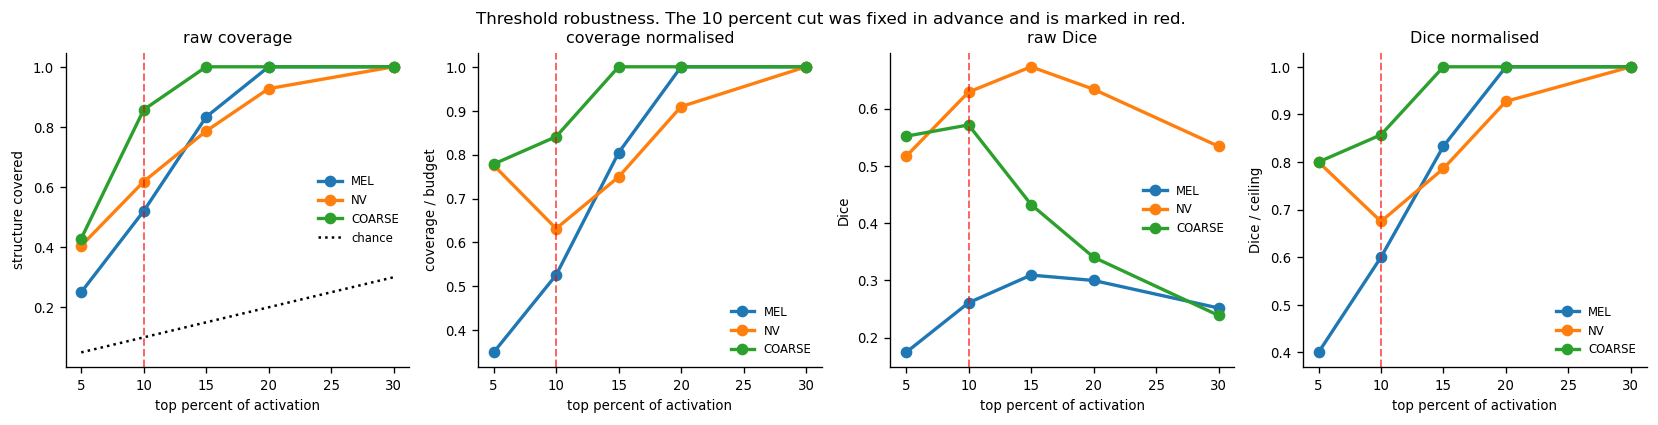


raw coverage
top_pct         5      10     15     20   30
label_group                                 
COARSE       0.429  0.857  1.000  1.000  1.0
MEL          0.250  0.520  0.833  1.000  1.0
NV           0.405  0.618  0.786  0.927  1.0
OTHER        0.500  0.667  1.000  1.000  1.0

coverage normalised
top_pct         5      10     15     20   30
label_group                                 
COARSE       0.779  0.841  1.000  1.000  1.0
MEL          0.350  0.526  0.804  1.000  1.0
NV           0.776  0.632  0.749  0.909  1.0
OTHER        0.473  0.629  1.000  1.000  1.0

raw Dice
top_pct         5      10     15     20     30
label_group                                   
COARSE       0.552  0.571  0.432  0.340  0.239
MEL          0.174  0.261  0.309  0.300  0.252
NV           0.517  0.629  0.673  0.634  0.534
OTHER        0.167  0.356  0.343  0.267  0.185

Dice normalised
top_pct       5      10     15     20   30
label_group                               
COARSE       0.8  0.857  1.000

In [6]:
# =============================================================================
# FIGURE 13.3  Threshold robustness check.
#
# NOT a selection procedure. The 10 percent cut was fixed in advance.
# This shows the conclusions do not depend on that choice.
#
# Selecting k percent of patches at random covers k percent of any structure
# on average, so the diagonal is chance. The right panel subtracts it.
#
# EXPECT the ordering of label groups to be stable across thresholds.
# READ   if MEL sits above chance at every threshold, the finding is robust.
# =============================================================================
g = (cov[cov.cam_type == "gradcam_a"]
     .groupby(["label_group", "top_pct"])
     .agg(cov_med=("struct_covered", "median"),
          cov_norm_med=("cov_norm", "median"),
          dice_med=("dice", "median"),
          dice_norm_med=("dice_norm", "median")).reset_index())

fig, ax = plt.subplots(1, 4, figsize=(17, 3.4))
panels = [("cov_med",       "structure covered",  "raw coverage"),
          ("cov_norm_med",  "coverage / budget",  "coverage normalised"),
          ("dice_med",      "Dice",               "raw Dice"),
          ("dice_norm_med", "Dice / ceiling",     "Dice normalised")]

for a, (col, ylab, title) in zip(ax, panels):
    for grp in ["MEL", "NV", "COARSE"]:
        s_ = g[g.label_group == grp]
        if len(s_):
            a.plot(s_.top_pct, s_[col], "o-", lw=2, ms=6, label=grp)
    if col == "cov_med":
        a.plot(SWEEP_PCTS, np.array(SWEEP_PCTS) / 100, "k:", lw=1.5,
               label="chance")
    a.axvline(MAIN_PCT, color="red", ls="--", lw=1.2, alpha=0.6)
    a.set_xlabel("top percent of activation")
    a.set_ylabel(ylab)
    a.set_title(title)
    a.legend(frameon=False, fontsize=7)

fig.suptitle("Threshold robustness. The 10 percent cut was fixed in advance "
             "and is marked in red.", fontsize=10)
fig.savefig(OUT / "threshold_robustness.png")
plt.show()

for col, name in [("cov_med", "raw coverage"),
                  ("cov_norm_med", "coverage normalised"),
                  ("dice_med", "raw Dice"),
                  ("dice_norm_med", "Dice normalised")]:
    print(f"\n{name}")
    print(g.pivot(index="label_group", columns="top_pct",
                  values=col).round(3).to_string())

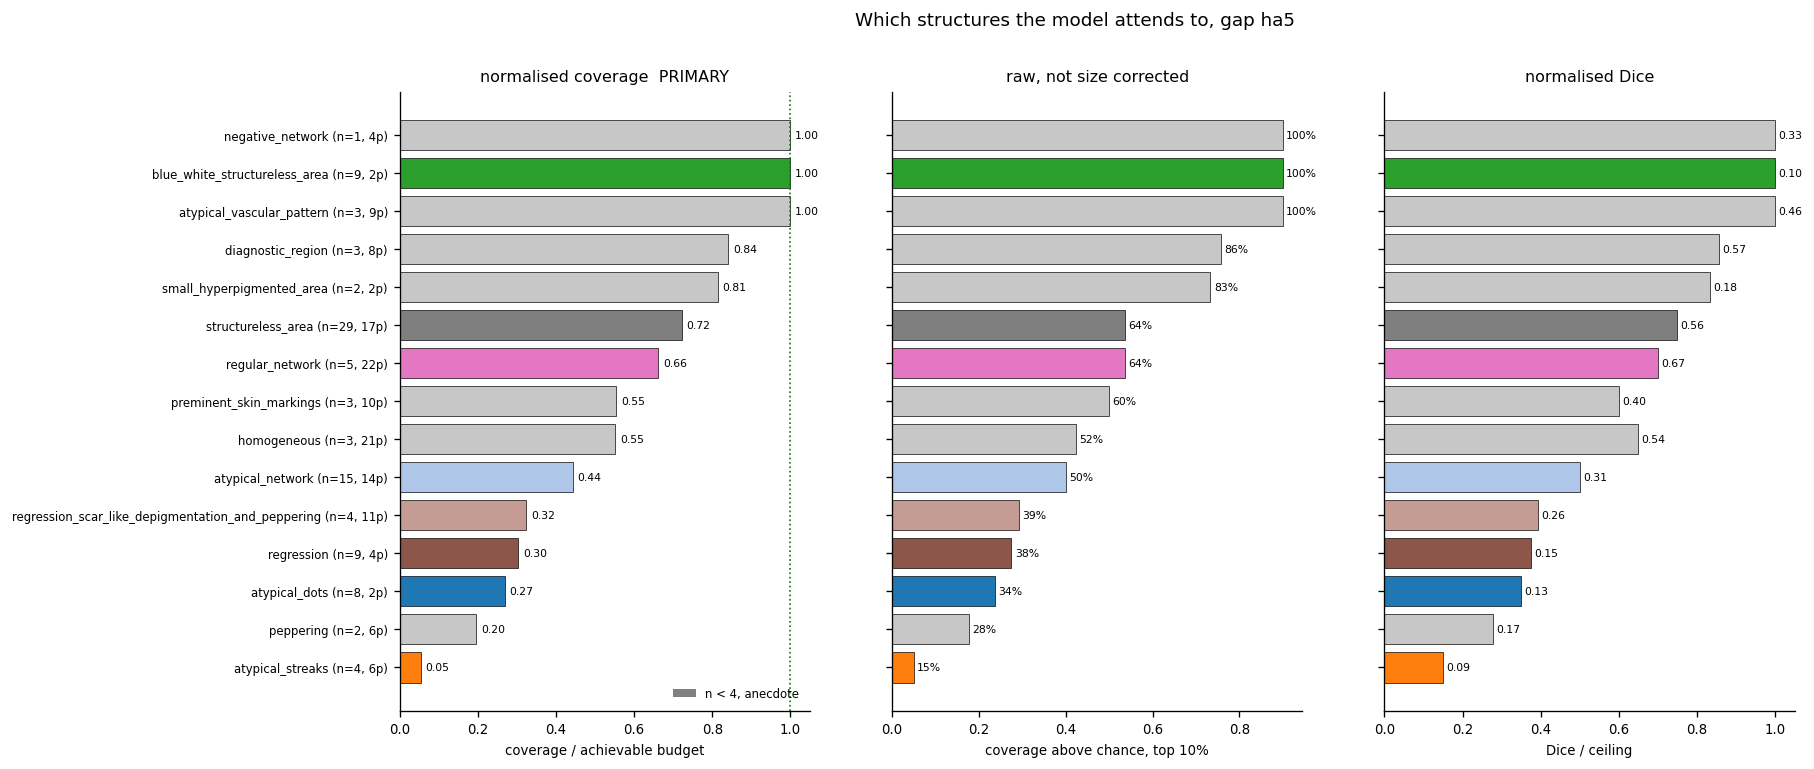

label_group                                             label  n  patches  cov_med  cov_ceil  cov_norm_med  above_chance  dice_med  dice_norm_med
        MEL                         atypical_vascular_pattern  3      9.0    1.000     1.000         1.000         0.900     0.462          1.000
        MEL                     blue_white_structureless_area  9      2.0    1.000     1.000         1.000         0.900     0.095          1.000
        MEL                                  negative_network  1      4.0    1.000     1.000         1.000         0.900     0.333          1.000
     COARSE                                 diagnostic_region  3      8.0    0.857     1.000         0.841         0.757     0.571          0.857
      OTHER                         small_hyperpigmented_area  2      2.5    0.833     1.000         0.814         0.733     0.178          0.833
        MEL                                structureless_area 29     17.0    0.636     1.000         0.722         0.536    

In [7]:
# =============================================================================
# FIGURE 13.4  Which structures does the model attend to.
#
# Ranked by cov_norm, coverage as a fraction of what the top-k budget
# allows. A structure larger than k patches cannot be fully covered, so
# raw coverage penalises large structures twice. This is the size
# normalisation the supervisor asked for.
#
# EXPECT ordering to differ from raw coverage. Large structures move up.
# WATCH  n below MIN_N shown in grey. anecdote, not evidence.
# =============================================================================
s = (cov[(cov.top_pct == MAIN_PCT) & (cov.cam_type == "gradcam_a")]
     .groupby(["label_group", "label"])
     .agg(n=("struct_covered", "size"),
          images=("image_id", "nunique"),
          cov_med=("struct_covered", "median"),
          cov_norm_med=("cov_norm", "median"),
          cov_ceil=("cov_ceiling", "median"),
          dice_med=("dice", "median"),
          dice_norm_med=("dice_norm", "median"),
          heat_med=("heat_on_struct", "median"),
          lift_med=("lift", "median"),
          area=("struct_area", "median"),
          patches=("struct_patches", "median"))
     .reset_index())
s["above_chance"] = s.cov_med - MAIN_PCT / 100
s = s.sort_values("cov_norm_med")

fig, ax = plt.subplots(1, 3, figsize=(15, 0.34 * len(s) + 1.6))
y = np.arange(len(s))
cols = [LABEL_COLOR[l] if n >= MIN_N else (0.78, 0.78, 0.78, 1)
        for l, n in zip(s.label, s.n)]

ax[0].barh(y, s.cov_norm_med, color=cols, edgecolor="black", linewidth=0.4)
ax[0].axvline(0, color="k", lw=1)
ax[0].axvline(1, color="green", ls=":", lw=1)
ax[0].set_yticks(y)
ax[0].set_yticklabels([f"{r.label} (n={r.n}, {r.patches:.0f}p)"
                       for _, r in s.iterrows()], fontsize=7)
ax[0].set_xlabel("coverage / achievable budget")
ax[0].set_title("normalised coverage  PRIMARY")
for i, r in enumerate(s.itertuples()):
    ax[0].text(r.cov_norm_med + 0.012, i, f"{r.cov_norm_med:.2f}",
               va="center", fontsize=6.5)

ax[1].barh(y, s.above_chance, color=cols, edgecolor="black", linewidth=0.4)
ax[1].axvline(0, color="k", lw=1)
ax[1].set_yticks(y); ax[1].set_yticklabels([])
ax[1].set_xlabel(f"coverage above chance, top {MAIN_PCT}%")
ax[1].set_title("raw, not size corrected")
for i, r in enumerate(s.itertuples()):
    ax[1].text(r.above_chance + 0.008, i, f"{r.cov_med*100:.0f}%",
               va="center", fontsize=6.5)

ax[2].barh(y, s.dice_norm_med, color=cols, edgecolor="black", linewidth=0.4)
ax[2].set_yticks(y); ax[2].set_yticklabels([])
ax[2].set_xlabel("Dice / ceiling")
ax[2].set_title("normalised Dice")
for i, r in enumerate(s.itertuples()):
    ax[2].text(r.dice_norm_med + 0.008, i, f"{r.dice_med:.2f}",
               va="center", fontsize=6.5)

ax[0].legend(handles=[Patch(facecolor="grey", label=f"n < {MIN_N}, anecdote")],
             frameon=False, fontsize=7, loc="lower right")
fig.suptitle(f"Which structures the model attends to, {POOL_TAG} {CKPT}",
             fontsize=11)
fig.savefig(OUT / "structure_ranking.png")
plt.show()

print(s.sort_values("cov_norm_med", ascending=False)
      [["label_group", "label", "n", "patches", "cov_med", "cov_ceil",
        "cov_norm_med", "above_chance", "dice_med", "dice_norm_med"]]
      .round(3).to_string(index=False))

In [8]:
# =============================================================================
# TABLE  Per label, GradCAM versus Finer-CAM.
#
# This is request 7. Columns are n, size, Dice for each CAM, the difference,
# AUC from 12c, and chance corrected coverage.
#
# EXPECT delta near zero everywhere. That is the E2 finding at label
#        resolution, and it holds because the target and reference class
#        maps are statistically indistinguishable.
#
# EXPLORATORY. Structures overlap spatially, so these rows are not
# independent and no p values are reported.
# =============================================================================
piv = (cov[cov.top_pct == MAIN_PCT]
       .pivot_table(index=["label_group", "label"], columns="cam_type",
                    values="dice", aggfunc="median"))

lab_auc = (long_df[(long_df.target_kind == "label") &
                   (long_df.cam_type.isin(["gradcam_a", "finercam"]))]
           .assign(label=lambda d: d.target.str.replace("label_", "", regex=False))
           .query("ckpt == @CKPT")
           .pivot_table(index="label", columns="cam_type",
                        values="cam_auc", aggfunc="median"))
tab = (s.set_index(["label_group", "label"])
       [["n", "images", "patches", "cov_med", "cov_ceil", "cov_norm_med",
         "above_chance", "lift_med"]]
       .join(piv[["gradcam_a", "finercam"]]
             .rename(columns={"gradcam_a": "dice_grad",
                              "finercam": "dice_finer"}))
       .reset_index()
       .merge(lab_auc.rename(columns={"gradcam_a": "auc_grad",
                                      "finercam": "auc_finer"}).reset_index(),
              on="label", how="left"))

tab["dice_delta"] = tab.dice_finer - tab.dice_grad
tab["auc_delta"]  = tab.auc_finer  - tab.auc_grad
tab["usable"]     = tab.n >= MIN_N
tab["pooling"]    = POOL_TAG

order = ["label_group", "label", "n", "images", "patches",
         "cov_med", "cov_ceil", "cov_norm_med", "above_chance", "lift_med",
         "dice_grad", "dice_finer", "dice_delta",
         "auc_grad", "auc_finer", "auc_delta", "usable"]
tab = tab[order].sort_values(["usable", "cov_norm_med"],
                             ascending=[False, False])
tab.to_csv(OUT / "per_label_table.csv", index=False)

print(f"PER LABEL, {POOL_TAG} {CKPT}, top {MAIN_PCT}%")
print("=" * 118)
print(tab.round(3).to_string(index=False))

u = tab[tab.usable]
print(f"\nusable labels: {len(u)} of {len(tab)}")
print(f"best localised    : {u.iloc[0].label} "
      f"(cov_norm {u.iloc[0].cov_norm_med:.2f})")
print(f"worst localised   : {u.iloc[-1].label} "
      f"(cov_norm {u.iloc[-1].cov_norm_med:.2f})")
print(f"median Dice delta, Finer minus Grad : {u.dice_delta.median():+.4f}")
print(f"median AUC delta                    : {u.auc_delta.median():+.4f}")
print(f"labels favouring Finer-CAM on Dice  : "
      f"{int((u.dice_delta > 0).sum())} of {len(u)}")

PER LABEL, gap ha5, top 10%
label_group                                             label  n  images  patches  cov_med  cov_ceil  cov_norm_med  above_chance  lift_med  dice_grad  dice_finer  dice_delta  auc_grad  auc_finer  auc_delta  usable
        MEL                     blue_white_structureless_area  9       9      2.0    1.000     1.000         1.000         0.900     9.800      0.095       0.182       0.087     0.944      0.940     -0.003    True
        MEL                                structureless_area 29      29     17.0    0.636     1.000         0.722         0.536     6.236      0.558       0.537      -0.022     0.961      0.942     -0.019    True
         NV                                   regular_network  5       5     22.0    0.636     0.909         0.662         0.536     6.236      0.667       0.682       0.015     0.961      0.964      0.004    True
        MEL                                  atypical_network 15      15     14.0    0.500     1.000         0.443  

In [9]:
# =============================================================================
# All 34 per image figures to disk. For the appendix and for Florentia.
# =============================================================================
import matplotlib
_backend = matplotlib.get_backend()
matplotlib.use("Agg")

ok, fail = 0, []
for iid in eval_df.image_id:
    try:
        structure_figure(iid, save=True, show=False)
        ok += 1
    except Exception as e:
        fail.append((iid, str(e)[:70]))

matplotlib.use(_backend)
print(f"written {ok} figures to {PER_IMG}")
for iid, e in fail:
    print(f"  failed {iid}: {e}")

written 34 figures to /Users/choekyelnyungmartsang/Developer/master-thesis/results/structure/gap/squash224/per_image


In [10]:
# =============================================================================
# What notebook 14 will consume.
# =============================================================================
print("=" * 76)
print(f"NOTEBOOK 13 COMPLETE, pooling = {POOL_TAG}")
print("=" * 76)
for f in sorted(OUT.glob("*.csv")) + sorted(OUT.glob("*.png")):
    print(f"  {f.relative_to(REPO)}")
print(f"  {PER_IMG.relative_to(REPO)}/  "
      f"{len(list(PER_IMG.glob('*.png')))} figures")

u = tab[tab.usable]
print(f"\nHEADLINES")
print(f"  usable labels               {len(u)} of {len(tab)} at n >= {MIN_N}")
print(f"  best structure              {u.iloc[0].label} "
      f"({u.iloc[0].cov_med*100:.0f}% covered, Dice {u.iloc[0].dice_grad:.2f})")
print(f"  worst structure             {u.iloc[-1].label} "
      f"({u.iloc[-1].cov_med*100:.0f}% covered, Dice {u.iloc[-1].dice_grad:.2f})")
print(f"  median Finer minus Grad     {u.dice_delta.median():+.4f} Dice")
print(f"  threshold                   {MAIN_PCT}%, fixed in advance, "
      f"robustness reported")
print(f"\nrerun with POOLING = 'cls' for the architectural replication.")

NOTEBOOK 13 COMPLETE, pooling = gap
  results/structure/gap/squash224/per_label_table.csv
  results/structure/gap/squash224/peripherality.csv
  results/structure/gap/squash224/structure_coverage_long.csv
  results/structure/gap/squash224/centre_bias.png
  results/structure/gap/squash224/label_distribution.png
  results/structure/gap/squash224/structure_ranking.png
  results/structure/gap/squash224/threshold_robustness.png
  results/structure/gap/squash224/per_image/  34 figures

HEADLINES
  usable labels               8 of 15 at n >= 4
  best structure              blue_white_structureless_area (100% covered, Dice 0.10)
  worst structure             atypical_streaks (15% covered, Dice 0.09)
  median Finer minus Grad     +0.0076 Dice
  threshold                   10%, fixed in advance, robustness reported

rerun with POOLING = 'cls' for the architectural replication.


n = 100 annotations, geometry squash224
peripherality vs cov_norm       rho -0.206  p 0.0397
peripherality vs raw coverage   rho -0.178  p 0.0760

positional prior control (scrambled input) rho -0.642
content driven component, approx           rho +0.436

most peripheral annotations:
    image_id            label  peripherality  struct_covered  cov_norm
ISIC_0030798 atypical_streaks          0.570           0.300     0.220
ISIC_0028999    atypical_dots          0.516           0.000    -0.114
ISIC_0031408 atypical_network          0.475           0.714     0.720
ISIC_0025132    atypical_dots          0.468           0.000    -0.114
ISIC_0025214       regression          0.465           0.000    -0.114
ISIC_0028944 atypical_streaks          0.396           0.000    -0.114
ISIC_0030798 atypical_network          0.361           0.500     0.443
ISIC_0026584 atypical_network          0.346           0.500     0.443

by label, median peripherality:
                                           

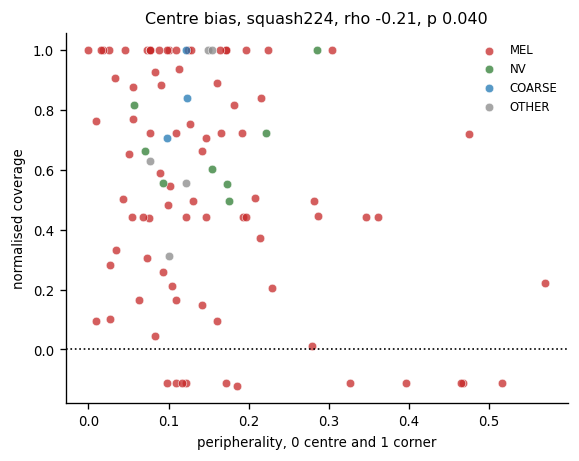

In [11]:
# =============================================================================
# Is the model centre biased.
#
# Note. A phase-scrambled control in 12b measured a learned centre prior on
# structure-free input, rho about -0.64 GAP and -0.70 CLS. Any bias found
# here should be compared against that baseline rather than interpreted as
# purely content driven.
#
# EXPECT some negative correlation, magnitude near or below the control.
# READ   if this rho is close to the control's, real content adds little.
#        if it is much stronger, real dermoscopic content adds a genuine
#        content driven component on top of the positional prior.
# =============================================================================
from scipy.stats import spearmanr

c0 = (CAM_GRID - 1) / 2
maxd = np.hypot(c0, c0)

rows = []
for iid in eval_df.image_id:
    for lab, (_, mg) in label_masks(iid).items():
        if mg.sum() == 0:
            continue
        ys, xs = np.nonzero(mg)
        rows.append({
            "image_id": iid, "label": lab,
            "peripherality": float(np.hypot(ys.mean() - c0,
                                            xs.mean() - c0) / maxd),
        })

per = (pd.DataFrame(rows)
       .merge(cov[(cov.top_pct == MAIN_PCT) & (cov.cam_type == "gradcam_a")]
              [["image_id", "label", "label_group", "cov_norm",
                "struct_covered", "struct_patches"]],
              on=["image_id", "label"]))
per["pooling"] = POOL_TAG
per["geometry"] = GEOMETRY
per.to_csv(OUT / "peripherality.csv", index=False)

d = per.dropna(subset=["cov_norm"])
r1 = spearmanr(d.peripherality, d.cov_norm)
r2 = spearmanr(d.peripherality, d.struct_covered)

print(f"n = {len(d)} annotations, geometry {GEOMETRY}")
print(f"peripherality vs cov_norm       rho {r1.statistic:+.3f}  p {r1.pvalue:.4f}")
print(f"peripherality vs raw coverage   rho {r2.statistic:+.3f}  p {r2.pvalue:.4f}")

ctrl_path = REPO / "outputs" / "mel_nv" / "eval_cams" / POOL_TAG / GEOMETRY / "positional_controls.csv"
if ctrl_path.exists():
    pc = pd.read_csv(ctrl_path)
    scr = pc[pc.control == "scrambled"]
    if len(scr):
        crho = scr.rho.iloc[0]
        print(f"\npositional prior control (scrambled input) rho {crho:+.3f}")
        print(f"content driven component, approx           rho "
              f"{r1.statistic - crho:+.3f}")

print("\nmost peripheral annotations:")
print(per.nlargest(8, "peripherality")
      [["image_id", "label", "peripherality", "struct_covered", "cov_norm"]]
      .round(3).to_string(index=False))

print("\nby label, median peripherality:")
print(per.groupby("label")[["peripherality", "cov_norm"]]
      .median().round(3).sort_values("peripherality",
                                     ascending=False).to_string())

fig, ax = plt.subplots(figsize=(5.4, 4.0))
for grp, col in [("MEL", "#C62828"), ("NV", "#2E7D32"),
                 ("COARSE", "#1F77B4"), ("OTHER", "#888888")]:
    sg = d[d.label_group == grp]
    if len(sg):
        ax.scatter(sg.peripherality, sg.cov_norm, s=26, alpha=0.75,
                   color=col, label=grp, edgecolor="white", linewidth=0.4)
ax.axhline(0, color="k", ls=":", lw=1)
ax.set_xlabel("peripherality, 0 centre and 1 corner")
ax.set_ylabel("normalised coverage")
ax.set_title(f"Centre bias, {GEOMETRY}, rho {r1.statistic:+.2f}, p {r1.pvalue:.3f}")
ax.legend(frameon=False, fontsize=7)
fig.savefig(OUT / "centre_bias.png")
plt.show()

In [12]:
from scipy.stats import rankdata, spearmanr
import numpy as np

d = per.dropna(subset=["cov_norm"]).copy()
d["log_size"] = np.log(d.struct_patches.clip(lower=1))

def partial_spearman(x, y, z):
    """rho between x and y, controlling for z, on ranks."""
    rx, ry, rz = (rankdata(v) for v in (x, y, z))
    Z = np.column_stack([np.ones_like(rz), rz])
    res = lambda v: v - Z @ np.linalg.lstsq(Z, v, rcond=None)[0]
    return spearmanr(res(rx), res(ry))

raw = spearmanr(d.peripherality, d.cov_norm)
par = partial_spearman(d.peripherality, d.cov_norm, d.log_size)
siz = spearmanr(d.log_size, d.cov_norm)
ps  = spearmanr(d.log_size, d.peripherality)

print(f"geometry {GEOMETRY}, pooling {POOL_TAG}\n")
print(f"peripherality vs coverage            rho {raw.statistic:+.3f}  p {raw.pvalue:.4f}")
print(f"  controlling for log size           rho {par.statistic:+.3f}  p {par.pvalue:.4f}")
print(f"size vs coverage                     rho {siz.statistic:+.3f}  p {siz.pvalue:.4f}")
print(f"size vs peripherality                rho {ps.statistic:+.3f}  p {ps.pvalue:.4f}")

geometry squash224, pooling gap

peripherality vs coverage            rho -0.206  p 0.0397
  controlling for log size           rho -0.223  p 0.0258
size vs coverage                     rho -0.130  p 0.1974
size vs peripherality                rho -0.204  p 0.0420


In [13]:
from PIL import Image as PILImage
pngs = sorted(PER_IMG.glob("*.png"))
imgs = [PILImage.open(p).convert("RGB") for p in pngs]
imgs[0].save(OUT / "structure_review.pdf", save_all=True,
             append_images=imgs[1:], resolution=150.0)
print(f"{len(imgs)} pages")

34 pages
